In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
path=os.path.dirname(os.getcwd())
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [113]:
palette = ['#6930C3',"#582f0e","#936639",'#E29578',"#c2c5aa","#a4ac86","#656d4a","#414833","#333d29"] #"#a68a64","#b6ad90",
method_baseline = ['origin','RW','DIremover','LFR','unconstrained','barycentre','ROC']
palette_our = ["#7BDFF2","#B2F7EF"]
method_our = ['partial_0.001','partial_0.01']
colors = dict(zip(method_baseline, palette[:len(method_baseline)]))
colors.update(dict(zip(method_our, palette_our)))

def load_report(dataname,pa,post):
    if post:
        report=pd.read_csv(path+'/data/report_postprocess_'+dataname+'_'+pa+'.csv')
    else:
        report=pd.read_csv(path+'/data/report_preprocess_'+dataname+'_'+pa+'.csv')
    report=report.rename(columns={"DI of pred":"DI"})
    performance=list(report.columns)[:-1]
    pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
    return pivot

In [120]:
5+0.12*5

5.6

C:\Users\zhouq\AppData\Local\Temp\ipykernel_14608\2778580025.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(performance, fontsize=11)
C:\Users\zhouq\AppData\Local\Temp\ipykernel_14608\2778580025.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(performance, fontsize=11)


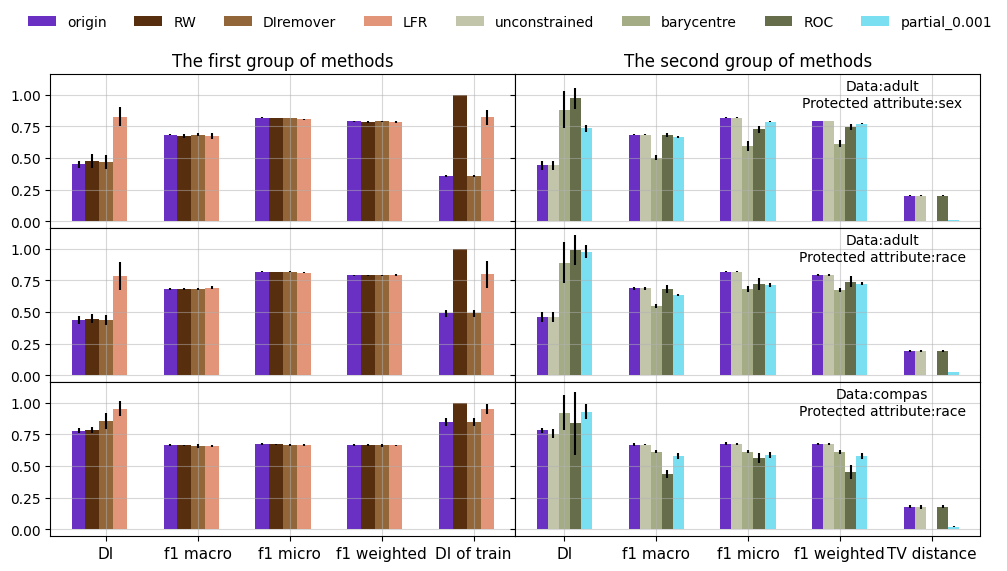

In [140]:
performance_common=['DI','f1 macro','f1 micro','f1 weighted']
methods_post=['origin','unconstrained','barycentre','ROC','partial_0.001']
methods_pre =['origin','RW','DIremover','LFR']
dataname_list = ['adult','adult','compas']
pa_list = ['sex','race','race']

ind=np.arange(len(performance_common)+1)

fig, ax = plt.subplots(3,2,figsize=(12,6),sharey=True)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
for i in range(3):
    for j in range(2):
        if j == 0:
            width = 0.15
            pivot=load_report(dataname_list[i],pa_list[i],post = False)
            methods=methods_pre
            performance=performance_common+['DI of train']
        elif j == 1:
            width = 0.12
            pivot=load_report(dataname_list[i],pa_list[i],post = True)
            methods=methods_post
            performance=performance_common+['TV distance']
            ax[i,j].text(3.7, 1,'Data:'+dataname_list[i]+'\n'+'Protected attribute:'+pa_list[i], horizontalalignment='center',
            verticalalignment='center')

        z=0
        for m in methods:
            sub=[pivot[('mean',p)][m] for p in performance]
            err=[pivot[('std',p)][m] for p in performance]
            ax[i,j].bar(ind+width*z,sub,width,yerr=err,color=colors[m],label=m)
            z+=1
        
        if i == 2:
            ax[i,j].set_xticklabels(performance, fontsize=11)
        else:
            ax[i,j].set_xticklabels([])
        ax[i,j].set_xticks(ind+width*2)
        ax[i,j].tick_params(axis='y', which='major', labelsize=10)
        ax[i,j].grid(alpha=0.5)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

ax[0,0].set_title('The first group of methods')
ax[0,1].set_title('The second group of methods')
lines_labels = [ax[0,j].get_legend_handles_labels() for j in [0,1]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lines.pop(4)
labels.pop(4)
fig.legend(lines, labels,fontsize=10,
            framealpha=0.2,bbox_to_anchor=(0.92,1.0),ncol=8,frameon=False)

plt.savefig(path+"/plots/E2.pdf",bbox_inches='tight')

# Pre

**Preprocess compas**

In [57]:
pa='race' #'sex' #'race'
report=pd.read_csv(path+'/data/report_preprocess_compas_'+str(pa)+'.csv')
performance=list(report.columns)[:-1]
methods=['origin','RW','DIremover','LFR'] #,'partial'
colors=['#5f0f40','#9a031e','red','#FF8811','#F4D06F'] #' dark purple
pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
pivot

C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\3561419528.py:6: FutureWarning: The provided callable <function mean at 0x000001C4176C8C10> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\3561419528.py:6: FutureWarning: The provided callable <function std at 0x000001C4176C8D30> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])


mean                                                    std  \
          DI of pred DI of train  f1 macro  f1 micro f1 weighted DI of pred   
method                                                                        
DIremover   0.836166    0.842171  0.664397  0.672657    0.669070   0.076150   
LFR         0.899979    0.925264  0.672272  0.678828    0.676801   0.053125   
RW          0.779673    1.000000  0.665513  0.675318    0.671122   0.018562   
origin      0.775968    0.842171  0.666996  0.676398    0.672441   0.023165   

                                                         
            DI of train  f1 macro  f1 micro f1 weighted  
method                                                   
DIremover  2.780257e-02  0.017626  0.011257    0.016277  
LFR        4.624930e-02  0.010579  0.009282    0.010263  
RW         2.243228e-14  0.007590  0.006933    0.007701  
origin     2.780257e-02  0.008261  0.006993    0.008247

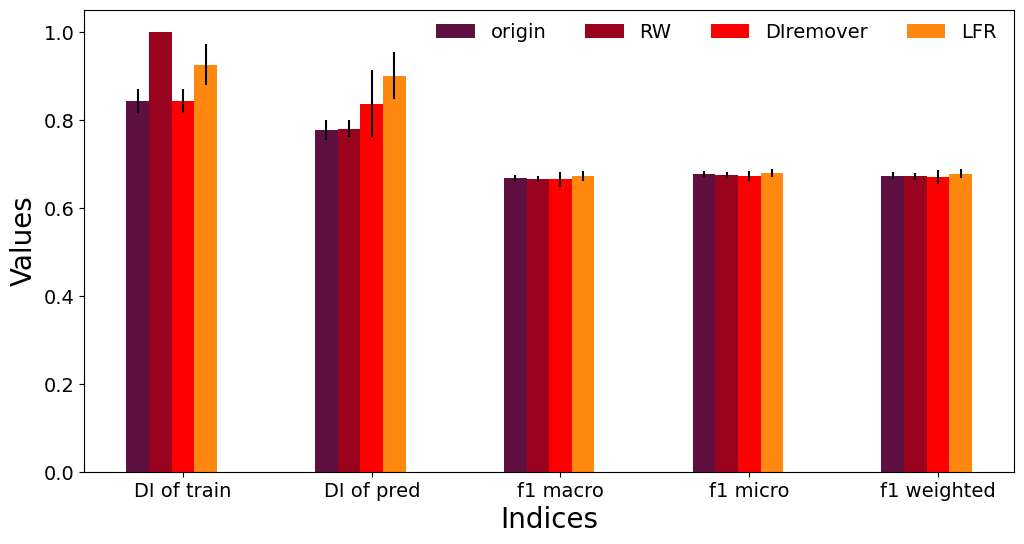

In [58]:
ind=np.arange(len(performance))
width = 0.12

fig, ax1 = plt.subplots(figsize=(12,6))

i=0
for m in methods:
    sub=[pivot[('mean',p)][m] for p in performance]
    err=[pivot[('std',p)][m] for p in performance]
    ax1.bar(ind+width*i,sub,width,yerr=err,color=colors[i],label=m)
    i+=1
ax1.legend(methods,fontsize=14,
            framealpha=0.2,bbox_to_anchor=(1.0,1.01),ncol=5,frameon=False)
ax1.set_xlabel('Indices', fontsize=20)
ax1.set_ylabel('Values', fontsize=20)

ax1.set_xticks(ind+width*2)
ax1.set_xticklabels(performance, fontsize=14)
ax1.tick_params(axis='y', which='major', labelsize=14)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.savefig(path+"/plots/compas_preprocess_"+pa+".pdf",bbox_inches='tight')

**Preprocess adult**

In [ ]:
pa='race' #'sex' #'race'
report=pd.read_csv(path+'/data/report_preprocess_adult_'+str(pa)+'.csv')
performance=list(report.columns)[:-1]
methods=['origin','RW','DIremover','LFR'] #,'partial'
colors=['#5f0f40','#9a031e','red','#FF8811','#F4D06F'] #' dark purple
pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
pivot

C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\750716813.py:6: FutureWarning: The provided callable <function mean at 0x000001C4176C8C10> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\750716813.py:6: FutureWarning: The provided callable <function std at 0x000001C4176C8D30> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])


mean                                                    std  \
          DI of pred DI of train  f1 macro  f1 micro f1 weighted DI of pred   
method                                                                        
DIremover   0.518291    0.475541  0.708810  0.819611    0.802626   0.040242   
LFR         0.823611    0.802312  0.696843  0.813645    0.795114   0.069635   
RW          0.511607    1.000000  0.707321  0.819699    0.802042   0.034937   
origin      0.518291    0.475541  0.708810  0.819611    0.802626   0.040242   

                                                         
            DI of train  f1 macro  f1 micro f1 weighted  
method                                                   
DIremover  2.127557e-02  0.006524  0.001696    0.003231  
LFR        9.768462e-02  0.013252  0.001591    0.005248  
RW         1.838482e-13  0.006583  0.001957    0.003294  
origin     2.127557e-02  0.006524  0.001696    0.003231

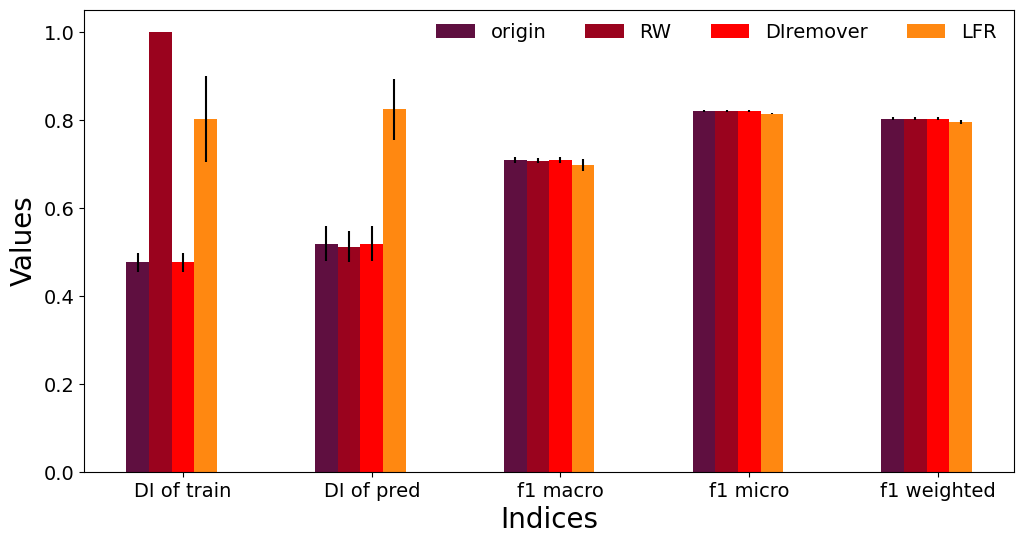

In [ ]:
ind=np.arange(len(performance))
width = 0.12

fig, ax1 = plt.subplots(figsize=(12,6))

i=0
for m in methods:
    sub=[pivot[('mean',p)][m] for p in performance]
    err=[pivot[('std',p)][m] for p in performance]
    ax1.bar(ind+width*i,sub,width,yerr=err,color=colors[i],label=m)
    i+=1
ax1.legend(methods,fontsize=14,
            framealpha=0.2,bbox_to_anchor=(1.0,1.01),ncol=5,frameon=False)
ax1.set_xlabel('Indices', fontsize=20)
ax1.set_ylabel('Values', fontsize=20)

ax1.set_xticks(ind+width*2)
ax1.set_xticklabels(performance, fontsize=14)
ax1.tick_params(axis='y', which='major', labelsize=14)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.savefig(path+"/plots/adult_preprocess_"+pa+".pdf",bbox_inches='tight')

## Post

**Postprocess compas**

In [51]:
pa='race'
report=pd.read_csv(path+'/data/report_postprocess_compas_'+pa+'_0.05.csv')
performance=list(report.columns)[:-1]
# methods=['origin','baseline','partial repair2','partial repair3','barycentre'] #,'partial repair4','barycentre'
methods=['origin','unconstrained','barycentre','ROC','partial_0.001']
#list(set(report['method']))
colors=['#5f0f40','#9a031e','red','#FF8811','#F4D06F'] #' dark purple
pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
pivot

C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\1203781807.py:8: FutureWarning: The provided callable <function mean at 0x000001C4176C8C10> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\1203781807.py:8: FutureWarning: The provided callable <function std at 0x000001C4176C8D30> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])


mean                                                   std  \
                     DI TV distance  f1 macro  f1 micro f1 weighted        DI   
method                                                                          
ROC            0.887277    0.177996  0.452365  0.577562    0.474050  0.193923   
barycentre     0.969489    0.000039  0.592310  0.593601    0.590415  0.115766   
origin         0.760408    0.177996  0.667714  0.674484    0.672213  0.013914   
partial_0.001  0.887826    0.020850  0.572782  0.578129    0.568360  0.083178   
unconstrained  0.741295    0.173479  0.664580  0.668449    0.667538  0.031086   

                                                           
              TV distance  f1 macro  f1 micro f1 weighted  
method                                                     
ROC              0.008334  0.033535  0.028538    0.038099  
barycentre       0.000054  0.018550  0.017568    0.019825  
origin           0.008334  0.012192  0.010305    0.011572  
partial_0.001    0.000807  0.023600  0.021460    0.025454  
unconstrained    0.008744  0.009227  0.010595    0.010212

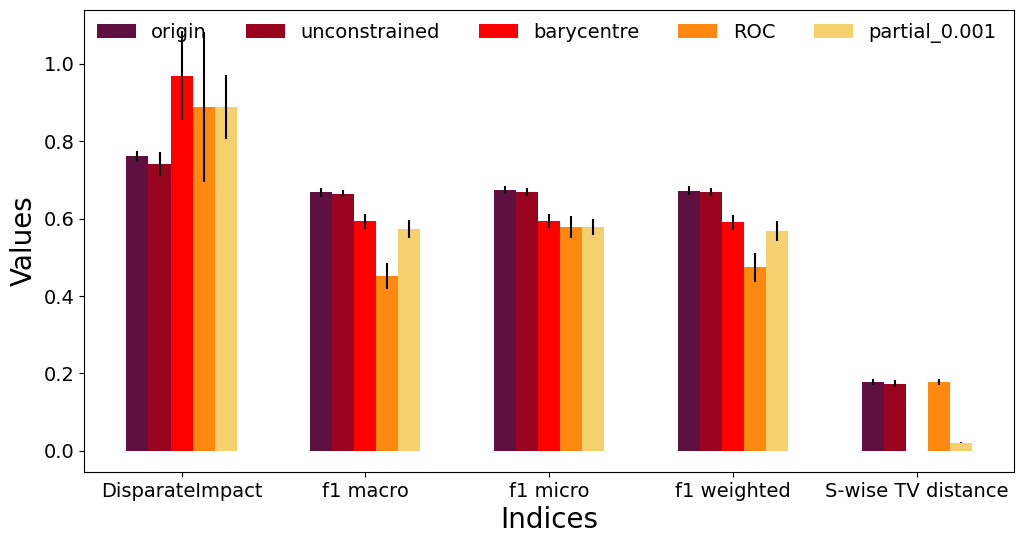

In [52]:
ind=np.arange(len(performance))
width = 0.12

fig, ax1 = plt.subplots(figsize=(12,6))

i=0
for m in methods:
    sub=[pivot[('mean',p)][m] for p in performance]
    err=[pivot[('std',p)][m] for p in performance]
    ax1.bar(ind+width*i,sub,width,yerr=err,color=colors[i],label=m)
    i+=1
# ['Origin','Baseline',r'$1e^{-2}$-repair',r'$1e^{-3}$-repair','Barycentre']
ax1.legend(methods,fontsize=14,
            framealpha=0.2,bbox_to_anchor=(1.0,1.01),ncol=5,frameon=False)
ax1.set_xlabel('Indices', fontsize=20)
ax1.set_ylabel('Values', fontsize=20)

ax1.set_xticks(ind+width*2)
ax1.set_xticklabels(['DisparateImpact']+[i for i in performance[1:-1]]+['S-wise TV distance'], fontsize=14)
ax1.tick_params(axis='y', which='major', labelsize=14)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.savefig(path+"/plots/compas_postprocess_0.05.pdf",bbox_inches='tight')

**Postprocess adult**

In [71]:
# report=pd.read_csv('C:/Users/zhouq/Documents/optimal_transport/report_postprocess_baryrace.csv')
pa='race'
report=pd.read_csv(path+'/data/report_postprocess_adult_'+pa+'_0.1.csv')
performance=list(report.columns)[:-1]
# methods=['origin','baseline','partial repair2','partial repair3','barycentre'] #,'partial repair4','barycentre'
methods=['origin','unconstrained','barycentre','ROC','partial_0.01']
#list(set(report['method']))
colors=['#5f0f40','#9a031e','red','#FF8811','#F4D06F'] #' dark purple
pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
pivot

C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\449080766.py:9: FutureWarning: The provided callable <function mean at 0x000001C4176C8C10> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
C:\Users\zhouq\AppData\Local\Temp\ipykernel_16192\449080766.py:9: FutureWarning: The provided callable <function std at 0x000001C4176C8D30> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])


mean                                                   std  \
                     DI TV distance  f1 macro  f1 micro f1 weighted        DI   
method                                                                          
ROC            0.838724    0.108527  0.720913  0.785586    0.790169  0.018948   
barycentre     0.966307    0.000082  0.521735  0.665575    0.658165  0.132022   
origin         0.684960    0.108527  0.684750  0.819044    0.791838  0.005767   
partial_0.01   0.693836    0.086843  0.682487  0.817901    0.790394  0.012823   
unconstrained  0.684960    0.108395  0.684750  0.819044    0.791838  0.005767   

                                                           
              TV distance  f1 macro  f1 micro f1 weighted  
method                                                     
ROC              0.003026  0.016704  0.034336    0.025432  
barycentre       0.000056  0.018331  0.009650    0.009058  
origin           0.003026  0.005188  0.000691    0.001463  
partial_0.01     0.003909  0.003168  0.003260    0.003080  
unconstrained    0.003007  0.005188  0.000691    0.001463

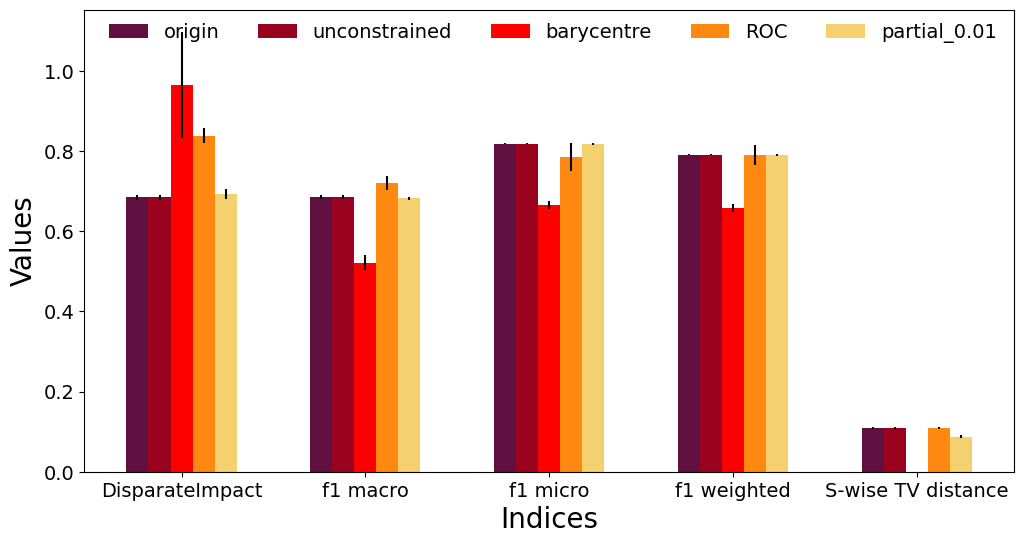

In [72]:
ind=np.arange(len(performance))
width = 0.12

fig, ax1 = plt.subplots(figsize=(12,6))

i=0
for m in methods:
    sub=[pivot[('mean',p)][m] for p in performance]
    err=[pivot[('std',p)][m] for p in performance]
    ax1.bar(ind+width*i,sub,width,yerr=err,color=colors[i],label=m)
    i+=1
# ['Origin','Baseline',r'$1e^{-2}$-repair',r'$1e^{-3}$-repair','Barycentre']
ax1.legend(methods,fontsize=14,
            framealpha=0.2,bbox_to_anchor=(1.0,1.01),ncol=5,frameon=False)
ax1.set_xlabel('Indices', fontsize=20)
ax1.set_ylabel('Values', fontsize=20)

ax1.set_xticks(ind+width*2)
ax1.set_xticklabels(['DisparateImpact']+[i for i in performance[1:-1]]+['S-wise TV distance'], fontsize=14)
ax1.tick_params(axis='y', which='major', labelsize=14)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# plt.savefig(path+"/plots/adult_postprocess_"+pa+".pdf",bbox_inches='tight')